# Scaling and Model Parameter Selection

In [1]:
from numpy import array, load, concatenate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split

In [1]:
total_features = []
total_labels = []

# Encoding between string class labels and numerical equivalents
occupation_classes = ['sports', 'creator', 'politics', 'performer']
occupation_dict = {0: 'sports', 1: 'creator', 2: 'politics', 3: 'performer'}

gender_classes = ['male', 'female']
gender_dict = {0: 'male', 1: 'female'}

features1_200 = load('1-200_features.npy')
labels1_200 = load('1-200_labels.npy')

# Concatenate all features/labels processed from dataset
total_features = concatenate((features1_200, load('201-400_features.npy'), load('401-600_features.npy'), \
                              load('601-800_features.npy'), load('801-1000_features.npy'), \
                              load('1001-1200_features.npy'), load('1201-1400_features.npy'), \
                              load('1401-1600_features.npy'), load('1601-1800_features.npy'), \
                             load('1801-1920_features.npy')), axis=0)
total_labels = concatenate((labels1_200, load('201-400_labels.npy'), load('401-600_labels.npy'), \
                           load('601-800_labels.npy'), load('801-1000_labels.npy'), \
                            load('1001-1200_labels.npy'), load('1201-1400_labels.npy'), \
                           load('1401-1600_labels.npy'), load('1601-1800_labels.npy'), \
                           load('1801-1920_labels.npy')), axis=0)

# Divide features into training and test sets
X_train, X_test, y_train, y_test = train_test_split(total_features, total_labels, test_size=0.2) # shuffle=False, might add back

# Function to scale input vectors
def scale(scaler, input_vector):
    scaler.fit(input_vector)
    scaled_features = scaler.transform(input_vector)
    return scaled_features

# Function to run 5-fold cross validation (with each type of model) to determine optimal hyperparameters for classifiers
def cross_validation(classifier, x_features, y_labels, params, metric):
    scoring_metric = 'f1_macro' if metric == None else metric # different metric for birth year
    clf = GridSearchCV(classifier, params, cv=5,
                       scoring=scoring_metric)  # training data is balanced, so f1 macro can be used
    clf.fit(x_features, y_labels)
    return clf.best_params_

# Train model on entire training set
def train_model(model, x_vector, y_vector):
    model.fit(x_vector, y_vector)
    return model

NameError: name 'load' is not defined

# 1     Logistic Regression
## 1.1 Model Training

In [18]:
from sklearn.linear_model import LogisticRegression

# Function to construct logistic regression params to pass to cross validation
def construct_logistic_params():
    return {'penalty': ['l1', 'l2'], 
            'C': [0.1, 0.5, 1],  # regularization penalty as param
            'solver': ['liblinear', 'saga']}

# Return logistic regression model with given params
def get_logistic_model(params):
    return LogisticRegression(penalty=params['penalty'], 
                         C=params['C'], 
                         solver=params['solver'])

# Construct params for every logistic classifier
logistic_params = construct_logistic_params()

In [19]:
# Separate y data into occupation, gender, and birth year labels
occupation_y_train = [int(y[2]) for y in y_train]
occupation_y_test = [int(y[2]) for y in y_test]

gender_y_train = [int(y[1]) for y in y_train]
gender_y_test = [int(y[1]) for y in y_test]

by_y_train = [int(y[0]) for y in y_train]
by_y_test = [int(y[0]) for y in y_test]

# (0) Scale training and test features
scaler = StandardScaler()
scaled_features = scale(scaler, X_train)

scaler = StandardScaler()
scaled_test_features = scale(scaler, X_test)

In [20]:
# OCCUPATION
# (1) Perform cross validation on occupation features with all chosen parameters
best_occupation_params = cross_validation(LogisticRegression(), scaled_features, occupation_y_train, \
                                          logistic_params, None)
print(best_occupation_params)

# (2) After determining optimal params based on macro f1 score, retrain model with those params
occupation_logistic_model = get_logistic_model(best_occupation_params)
trained_occupations_model = train_model(occupation_logistic_model, scaled_features, occupation_y_train)

C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Defau

C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge

C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Defau

{'C': 0.5, 'penalty': 'l1', 'solver': 'saga'}


C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)


In [21]:
# GENDER
best_gender_params = cross_validation(LogisticRegression(), scaled_features, gender_y_train, \
                                      logistic_params, None)
print(best_gender_params)

gender_logistic_model = get_logistic_model(best_gender_params)
trained_gender_model = train_model(gender_logistic_model, scaled_features, gender_y_train) 

C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\An

{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [22]:
# BIRTH YEAR
best_by_params = cross_validation(LogisticRegression(), scaled_features, by_y_train, logistic_params, 'f1_micro')
print(best_by_params)

by_logistic_model = get_logistic_model(best_by_params)
trained_by_model = train_model(by_logistic_model, scaled_features, by_y_train) 

C:\Anaconda\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 2 members, which is too few. The minimum number of members in any class cannot be less than n_splits=5.
  % (min_groups, self.n_splits)), Warning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\

C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\sag.py:334: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  "the coef_ did not converge", ConvergenceWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify 

C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Defau

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


## 1.2 Results

In [24]:
from random import randint
from sklearn.dummy import DummyClassifier
from yellowbrick.classifier import ClassPredictionError, ClassificationReport, ConfusionMatrix
import matplotlib.pyplot as plt
from yellowbrick.style import set_palette
    
set_palette('set1') 

In [25]:
# Function to produce visualization of metrics (precision, recall, f1)
def predict_metrics(model, test_features, test_labels, class_labels):
    fig = plt.figure()
    ax = fig.add_subplot()
    visualizer = ClassificationReport(model, classes=class_labels, support=True, ax=ax)
    print("Accuracy: %s" % visualizer.score(test_features, test_labels))
    g = visualizer.poof()

In [26]:
# Function to produce confusion matrix with true class vs. predicted class
def confusion_matrix(model, test_features, test_labels, class_labels, class_dict):
    fig = plt.figure()
    ax = fig.add_subplot()
    confusion_matrix = ConfusionMatrix(model, classes=class_labels, label_encoder=class_dict)
    confusion_matrix.score(test_features, test_labels)
    g = confusion_matrix.poof()

In [27]:
# Metric defined by PAN competition to combine scores from all three classifications
def c_rank(occupation_f1, gender_f1, by_f1):
    return 3 / ((1 / occupation_f1) + (1 / gender_f1) + (1 / by_f1))

In [29]:
# Construct dummy classifiers for occupation, gender, and birth year for comparison
# Occupation predictions based on dummy classifier
dummy_occupation_classifier = DummyClassifier()
trained_dummy_occupation_classifier = train_model(dummy_occupation_classifier, scaled_features, occupation_y_train)

# Gender predictions based on dummy classifier
dummy_gender_classifier = DummyClassifier()
trained_dummy_gender_classifier = train_model(dummy_gender_classifier, scaled_features, gender_y_train)

# Birth year predictions based on dummy classifier
dummy_by_classifier = DummyClassifier()
trained_dummy_by_classifier = train_model(dummy_by_classifier, scaled_features, by_y_train)

Accuracy: 0.21354166666666666


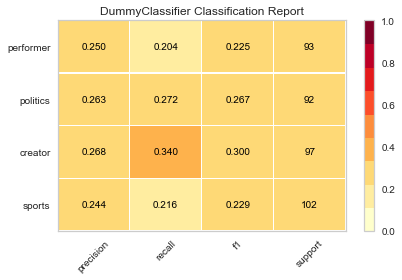

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


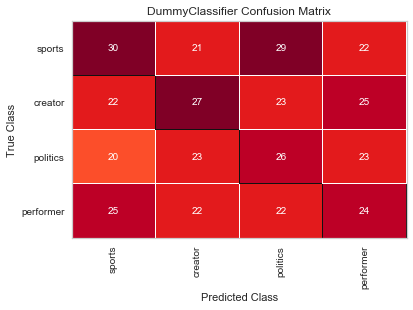

Accuracy: 0.7630208333333334


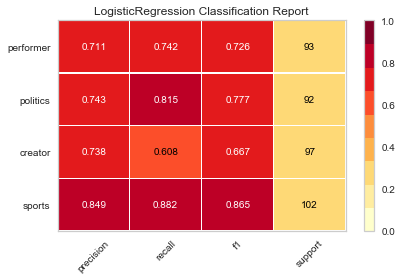

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


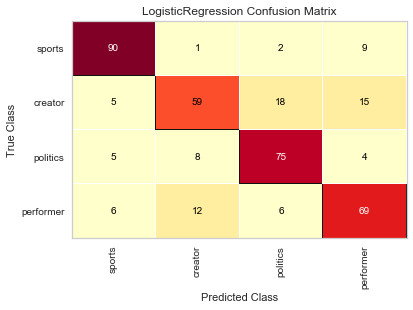

In [30]:
# Occupation metrics for Dummy classifier
predict_metrics(trained_dummy_occupation_classifier, scaled_test_features, occupation_y_test, occupation_classes)
confusion_matrix(trained_dummy_occupation_classifier, scaled_test_features, occupation_y_test, occupation_classes, occupation_dict)

# Occupation metrics for occupation classifier
predict_metrics(trained_occupations_model, scaled_test_features, occupation_y_test, occupation_classes)
confusion_matrix(trained_occupations_model, scaled_test_features, occupation_y_test, occupation_classes, occupation_dict)

Accuracy: 0.5208333333333334


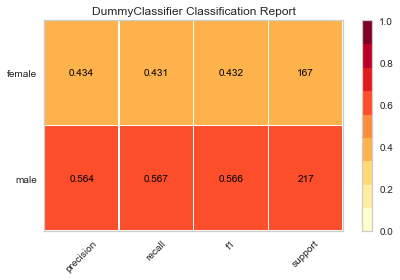

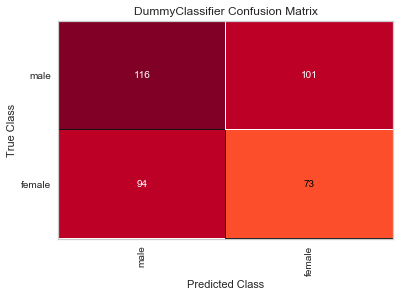

Accuracy: 0.7526041666666666


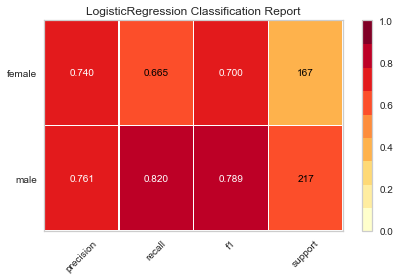

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


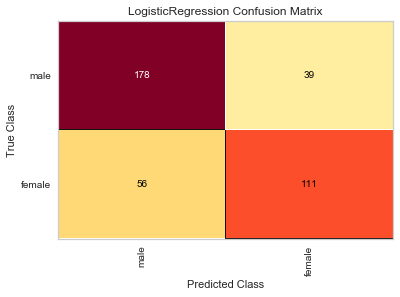

In [31]:
# Gender metrics for Dummy classifier
predict_metrics(trained_dummy_gender_classifier, scaled_test_features, gender_y_test, gender_classes)
confusion_matrix(trained_dummy_gender_classifier, scaled_test_features, gender_y_test, gender_classes, gender_dict)

# Gender metrics for gender classifier
predict_metrics(trained_gender_model, scaled_test_features, gender_y_test, gender_classes)
confusion_matrix(trained_gender_model, scaled_test_features, gender_y_test, gender_classes, gender_dict)

In [32]:
# scale for error window of birth year predictions based on birth year decade
margin_dict = {'4': 8, '5': 7, '6': 6, '7': 5, '8': 4, '9': 3}

# determine if birth year is within range of correct answer, based on PAN equation:
def birth_year_in_range(pred_birth_year, actual_birth_year, error_window):
    valid_by = 1 if actual_birth_year - error_window <= pred_birth_year <= actual_birth_year + error_window else 0
    return valid_by

# Custom micro f1 score for birth year based on PAN requirements
def birth_year_f1_score(y_actual, y_pred):
    tp = 0
    sample_size = len(y_actual)
    for index in range(0, sample_size):
        tp += birth_year_in_range(y_pred[index], y_actual[index], margin_dict[str(y_actual[index])[2]])
     
    return tp / sample_size

In [33]:
from sklearn.metrics import precision_recall_fscore_support

print('Dummy classifier')
print("Accuracy: %s" % trained_dummy_by_classifier.score(scaled_test_features, by_y_test))
y_pred = trained_dummy_by_classifier.predict(scaled_test_features)
print("Precision, recall, f-score:")
print(precision_recall_fscore_support(by_y_test, y_pred, average='micro'))
print('Custom F-Score:')
print(birth_year_f1_score(by_y_test, y_pred))
print()

print('Actual classifier')
print("Accuracy: %s" % trained_by_model.score(scaled_test_features, by_y_test))
y_pred = trained_by_model.predict(scaled_test_features)
print("Precision, recall, f-score:")
print(precision_recall_fscore_support(by_y_test, y_pred, average='micro'))
print('Custom F-Score:')
custom_by_f1_score = birth_year_f1_score(by_y_test, y_pred)
print(custom_by_f1_score)

Dummy classifier
Accuracy: 0.020833333333333332
Precision, recall, f-score:
(0.013020833333333334, 0.013020833333333334, 0.013020833333333334, None)
Custom F-Score:
0.2109375

Actual classifier
Accuracy: 0.052083333333333336
Precision, recall, f-score:
(0.052083333333333336, 0.052083333333333336, 0.052083333333333336, None)
Custom F-Score:
0.4140625


### 1.2.1 Logistic Regression C-Rank

In [34]:
from sklearn.metrics import f1_score

# Special metric devised by PAN for 2020 Profiling competition
occupation_lr_fscore = f1_score(occupation_y_test, trained_occupations_model.predict(scaled_test_features), average='micro')
gender_lr_fscore = f1_score(gender_y_test, trained_gender_model.predict(scaled_test_features), average='micro')
print('C-Rank Score: %s' % c_rank(occupation_lr_fscore, gender_lr_fscore, custom_by_f1_score))

C-Rank Score: 0.5935429333718929


# 2     Random Forest
## 2.1 Model Training

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Construct params dictionary to pass to cross validation
def construct_rf_params():
    return {'n_estimators': [50, 500, 700], 
            'max_depth': [None, 2, 5],
            'max_features': ['auto', 'log2']} # Having no max takes too long, may add later

# Return Random Forest model with given params
def get_rf_model(params):
    return RandomForestClassifier(n_estimators=params['n_estimators'], 
                         max_depth=params['max_depth'], 
                         max_features=params['max_features'])

# drop out unimportant features from RF model
def drop_features(model, x_vector, y_vector):
    selected_features_model = SelectFromModel(model)
    selected_features_model.fit(x_vector, y_vector)
    return selected_features_model

rf_params = construct_rf_params()

In [36]:
# OCCUPATION
# (1) Perform cross validation on occupation features with all chosen parameters
rf_best_occupation_params = cross_validation(RandomForestClassifier(), scaled_features, occupation_y_train, \
                                             rf_params, None)
print(rf_best_occupation_params)

# # (2) After determining optimal params based on f1 score, retrain model with those params
occupation_rf_model = get_rf_model(rf_best_occupation_params)
trained_occupations_rf_model = train_model(occupation_rf_model, scaled_features, occupation_y_train)

C:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


{'max_depth': None, 'max_features': 'auto', 'n_estimators': 700}


In [40]:
# GENDER
rf_best_gender_params = cross_validation(RandomForestClassifier(), scaled_features, gender_y_train, rf_params, None)
print(rf_best_gender_params)

gender_rf_model = get_rf_model(rf_best_gender_params)
trained_gender_rf_model = train_model(gender_rf_model, scaled_features, gender_y_train) 

{'max_depth': None, 'max_features': 'auto', 'n_estimators': 500}


In [41]:
# BIRTH YEAR
rf_best_by_params = cross_validation(RandomForestClassifier(), scaled_features, by_y_train, rf_params, 'f1_micro')
print(rf_best_by_params)

by_rf_model = get_rf_model(rf_best_by_params)
trained_by_rf_model = train_model(by_rf_model, scaled_features, by_y_train) 

C:\Anaconda\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 2 members, which is too few. The minimum number of members in any class cannot be less than n_splits=5.
  % (min_groups, self.n_splits)), Warning)
C:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


{'max_depth': 5, 'max_features': 'auto', 'n_estimators': 700}


## 2.2 Results

Accuracy: 0.7578125


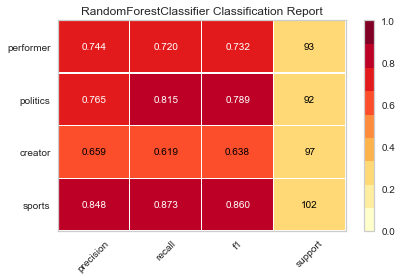

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


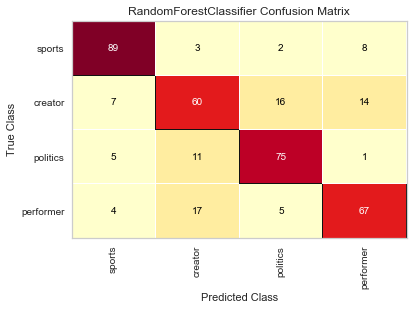

In [42]:
# Occupation metrics for occupation classifier
predict_metrics(trained_occupations_rf_model, scaled_test_features, occupation_y_test, occupation_classes)
confusion_matrix(trained_occupations_rf_model, scaled_test_features, occupation_y_test, occupation_classes, occupation_dict)

OCCUPATION WITH DROPPED FEATURES
Accuracy: 0.7682291666666666


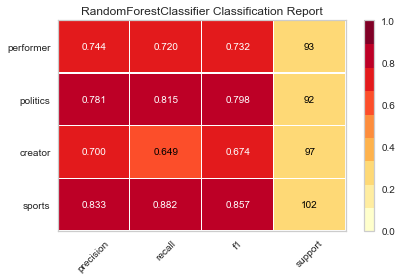

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


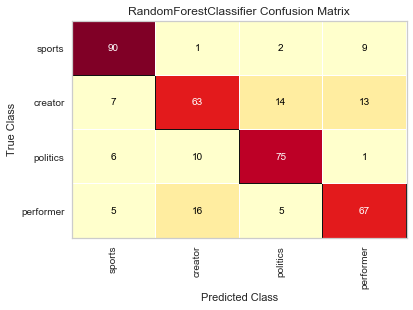

In [43]:
# Drop unimportant features from occupation model, re-train, and check metrics
dropped_occupation_rf_model = drop_features(trained_occupations_rf_model, scaled_features, occupation_y_train)
important_occupation_features = dropped_occupation_rf_model.transform(scaled_features)
important_test_occupation_features = dropped_occupation_rf_model.transform(scaled_test_features)
rf_occupation_model_dropped = train_model(occupation_rf_model, important_occupation_features, occupation_y_train)

# Occupation metrics for occupation classifier with dropped features
print("OCCUPATION WITH DROPPED FEATURES")
predict_metrics(rf_occupation_model_dropped, important_test_occupation_features, occupation_y_test, occupation_classes)
confusion_matrix(rf_occupation_model_dropped, important_test_occupation_features, occupation_y_test, occupation_classes, occupation_dict)

Accuracy: 0.7239583333333334


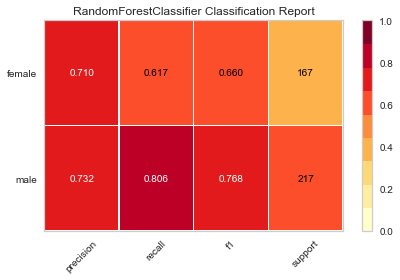

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


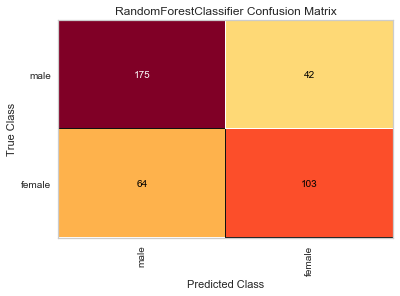

In [44]:
# gender metrics for gender classifier
predict_metrics(trained_gender_rf_model, scaled_test_features, gender_y_test, gender_classes)
confusion_matrix(trained_gender_rf_model, scaled_test_features, gender_y_test, gender_classes, gender_dict)

GENDER WITH DROPPED FEATURES
Accuracy: 0.75


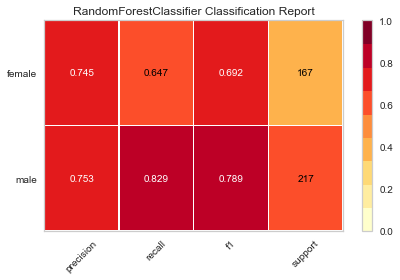

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


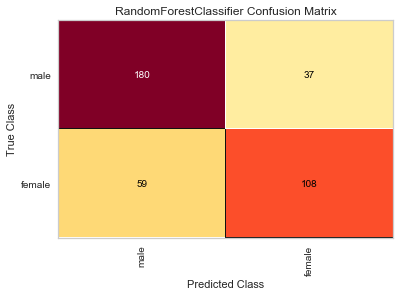

In [45]:
# Drop unimportant features from gender model, re-train, and check metrics
dropped_gender_rf_model = drop_features(trained_gender_rf_model, scaled_features, gender_y_train)
important_gender_features = dropped_gender_rf_model.transform(scaled_features)
important_test_gender_features = dropped_gender_rf_model.transform(scaled_test_features)
rf_gender_model_dropped = train_model(gender_rf_model, important_gender_features, gender_y_train)

# gender metrics with dropped features
print("GENDER WITH DROPPED FEATURES")
predict_metrics(rf_gender_model_dropped, important_test_gender_features, gender_y_test, gender_classes)
confusion_matrix(rf_gender_model_dropped, important_test_gender_features, gender_y_test, gender_classes, gender_dict)

In [46]:
# Birth year metrics for classifier
print('Actual classifier')
print("Accuracy: %s" % trained_by_rf_model.score(scaled_test_features, by_y_test))
y_pred = trained_by_rf_model.predict(scaled_test_features)
print("Precision, recall, f-score:")
print(precision_recall_fscore_support(by_y_test, y_pred, average='micro'))
print('Custom F-Score:')
custom_by_f1_score = birth_year_f1_score(by_y_test, y_pred)
print(custom_by_f1_score)

Actual classifier
Accuracy: 0.046875
Precision, recall, f-score:
(0.046875, 0.046875, 0.046875, None)
Custom F-Score:
0.421875


In [47]:
# Drop unimportant features from birth year model, re-train, and check metrics
by_rf_model = get_rf_model(rf_best_by_params)

trained_by_rf_model = train_model(by_rf_model, scaled_features, by_y_train)

dropped_by_rf_model = drop_features(trained_by_rf_model, scaled_features, by_y_train)
important_by_features = dropped_by_rf_model.transform(scaled_features)
important_test_by_features = dropped_by_rf_model.transform(scaled_test_features)
rf_by_model_dropped = train_model(by_rf_model, important_by_features, by_y_train)

# Find metrics for dropped birth year model
print("BIRTH YEAR WITH DROPPED FEATURES")
print('Actual classifier')
print("Accuracy: %s" % rf_by_model_dropped.score(important_test_by_features, by_y_test))
y_pred = rf_by_model_dropped.predict(important_test_by_features)
print("Precision, recall, f-score:")
print(precision_recall_fscore_support(by_y_test, y_pred, average='micro'))
print('Custom F-Score:')
custom_dropped_by_f1_score = birth_year_f1_score(by_y_test, y_pred)
print(custom_dropped_by_f1_score)

BIRTH YEAR WITH DROPPED FEATURES
Actual classifier
Accuracy: 0.046875
Precision, recall, f-score:
(0.046875, 0.046875, 0.046875, None)
Custom F-Score:
0.4088541666666667


### 2.2.1 Random Forest C-Rank

In [48]:
# Combined c rank for random forest
occupation_rf_fscore = f1_score(occupation_y_test, rf_occupation_model_dropped.predict(important_test_occupation_features), average='micro')
gender_rf_fscore = f1_score(gender_y_test, rf_gender_model_dropped.predict(important_test_gender_features), average='micro')
print('C-Rank Score: %s' % c_rank(occupation_rf_fscore, gender_rf_fscore, custom_dropped_by_f1_score))

C-Rank Score: 0.590447954853222


# 3 Support-Vector Classification
## 3.1 Model Training

In [49]:
from sklearn.svm import SVC

# Function to construct svc params to pass to cross validation
def construct_svc_params():
    return {'C': [0.005, 0.01, 0.1], 
            'kernel': ['linear', 'poly', 'rbf'],
            'gamma': [0.01, 0.1, 1]}

# Return logistic regression model with given params
def get_svc_model(params):
    return SVC(C=params['C'], kernel=params['kernel'], gamma=params['gamma'])

svc_params = construct_svc_params()

In [50]:
# (1) Perform cross validation on occupation features with all chosen parameters
best_svc_occupation_params = cross_validation(SVC(), scaled_features, occupation_y_train, \
                                          svc_params, None)
print(best_svc_occupation_params)

# (2) After determining optimal params based on macro f1 score, retrain model with those params
occupation_svc_model = get_svc_model(best_svc_occupation_params)
trained_occupations_svc_model = train_model(occupation_svc_model, scaled_features, occupation_y_train)

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

{'C': 0.1, 'gamma': 0.01, 'kernel': 'poly'}


In [51]:
# GENDER
best_svc_gender_params = cross_validation(SVC(), scaled_features, gender_y_train, \
                                      svc_params, None)
print(best_svc_gender_params)

gender_svc_model = get_svc_model(best_svc_gender_params)
trained_gender_svc_model = train_model(gender_svc_model, scaled_features, gender_y_train) 

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-def

{'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}


In [52]:
# BIRTH YEAR
best_svc_by_params = cross_validation(SVC(), scaled_features, by_y_train, svc_params, 'f1_micro')
print(best_svc_by_params)

by_svc_model = get_svc_model(best_svc_by_params)
trained_by_svc_model = train_model(by_svc_model, scaled_features, by_y_train) 

C:\Anaconda\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 2 members, which is too few. The minimum number of members in any class cannot be less than n_splits=5.
  % (min_groups, self.n_splits)), Warning)
C:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


{'C': 0.01, 'gamma': 0.01, 'kernel': 'linear'}


## 3.2 Results

Accuracy: 0.7421875


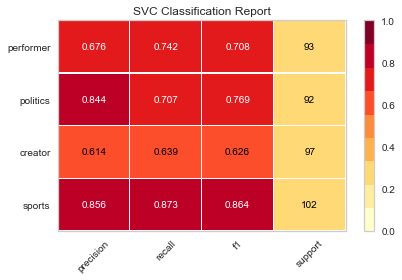

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


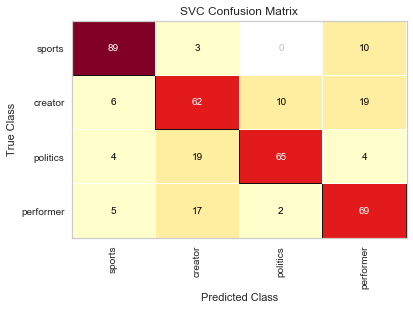

In [53]:
# Occupation metrics for occupation classifier
predict_metrics(trained_occupations_svc_model, scaled_test_features, occupation_y_test, occupation_classes)
confusion_matrix(trained_occupations_svc_model, scaled_test_features, occupation_y_test, occupation_classes, occupation_dict)

Accuracy: 0.765625


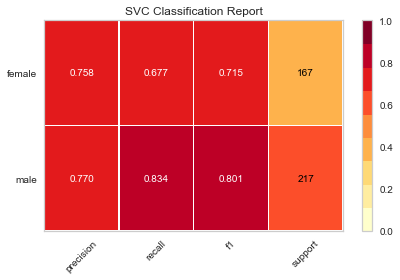

C:\Anaconda\lib\site-packages\sklearn\metrics\classification.py:182: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


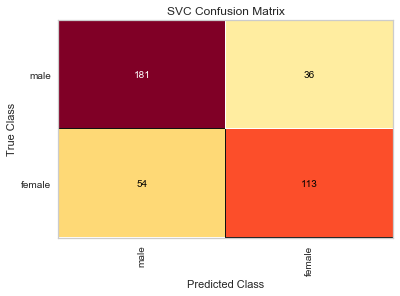

In [54]:
# gender metrics for gender classifier
predict_metrics(trained_gender_svc_model, scaled_test_features, gender_y_test, gender_classes)
confusion_matrix(trained_gender_svc_model, scaled_test_features, gender_y_test, gender_classes, gender_dict)

In [55]:
print('Actual classifier')
print("Accuracy: %s" % trained_by_svc_model.score(scaled_test_features, by_y_test))
y_pred = trained_by_svc_model.predict(scaled_test_features)
print("Precision, recall, f-score:")
print(precision_recall_fscore_support(by_y_test, y_pred, average='micro'))
print('Custom F-Score:')
custom_by_f1_score = birth_year_f1_score(by_y_test, y_pred)
print(custom_by_f1_score)

Actual classifier
Accuracy: 0.044270833333333336
Precision, recall, f-score:
(0.044270833333333336, 0.044270833333333336, 0.044270833333333336, None)
Custom F-Score:
0.4114583333333333


### 3.2.1 SVC C-rank

In [56]:
# C rank for all svc classifiers
occupation_svc_fscore = f1_score(occupation_y_test, trained_occupations_svc_model.predict(scaled_test_features), average='micro')
gender_svc_fscore = f1_score(gender_y_test, trained_gender_svc_model.predict(scaled_test_features), average='micro')
print('C-Rank Score: %s' % c_rank(occupation_svc_fscore, gender_svc_fscore, custom_by_f1_score))

C-Rank Score: 0.5901015635697658


In [57]:
# C-rank for highest f-scores for each category (occupation = linear regression, gender = random forest, birth year = svc)
print('C-Rank Score: %s' % c_rank(occupation_lr_fscore, gender_rf_fscore, custom_by_f1_score))

C-Rank Score: 0.5912153341431021


# Final Output

In [65]:
import ndjson

final_prediction_list = []

occupation_predictions = trained_occupations_svc_model.predict(scaled_test_features)
gender_predictions = trained_gender_svc_model.predict(scaled_test_features)
by_predictions = trained_by_svc_model.predict(scaled_test_features)

for i in range(0, len(occupation_predictions)):
    occupation_label = occupation_dict[occupation_predictions[i]]
    gender_label = gender_dict[gender_predictions[i]]
    by_label = int(by_predictions[i])
    celeb_prediction = {"id": i + 1, "occupation": occupation_label, "gender": gender_label, \
                       "birthyear": by_label}  # modify to include real ID when retrieved
    final_prediction_list.append(celeb_prediction)
    
# print(final_prediction_list)
    
with open('./test.ndjson', 'w') as file:  # replace with name 'labels.ndjson eventually'
    writer = ndjson.writer(file, ensure_ascii=False)
    for prediction in final_prediction_list:
        writer.writerow(prediction)